In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os

In [17]:
data = pd.read_excel(r"C:\Users\brian\OneDrive\Desktop\Amazon.xlsx")
data.head()

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43


In [18]:
#Vamos a dejar solo las columnas numericas y guardar los nombres de los clientes aparte, para despues identificarlos 
data = data.rename(columns = {'Unnamed: 0':'Cliente'})
data.head()
nombres = data['Cliente']
X = data.drop(columns = ['Cliente'])

In [19]:
#Vamos a estandarizar los datos 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scale = scaler.fit_transform(X)
data_scale

array([[ 1.20323754, -0.85570178,  0.57137311,  0.75217596, -0.13889518,
        -0.08973907, -0.79595768, -0.98297775, -0.96213678],
       [-0.86985105, -0.67018378,  0.41102518, -0.91510753, -0.04985981,
        -2.07234645, -0.69782003,  0.77947773, -0.01886543],
       [-0.78523519, -0.50012561,  0.25067726, -1.16272389,  1.55277686,
         0.32765196, -0.70395363, -0.93755364,  0.40989428],
       [ 0.46284876, -0.82478211,  0.62482242,  1.24740868, -0.6731074 ,
        -0.08973907, -0.71622084,  0.59778129, -0.96213678],
       [-0.93331294, -0.20638878, -1.01607136, -0.86558426,  0.75145853,
         2.31025933,  0.42462935, -0.86487506,  1.26741369],
       [ 0.03976945,  1.64879124,  0.83861965, -0.98939243,  0.03917556,
        -0.5071301 ,  2.01936616, -0.97389292, -2.16266395],
       [-0.72177329, -0.71656328,  1.26621412, -0.91510753,  0.8404939 ,
         2.20591158, -0.72235444, -0.91029917,  0.2383904 ],
       [-0.27754002, -0.57742478, -1.10693518,  0.91725354,  0

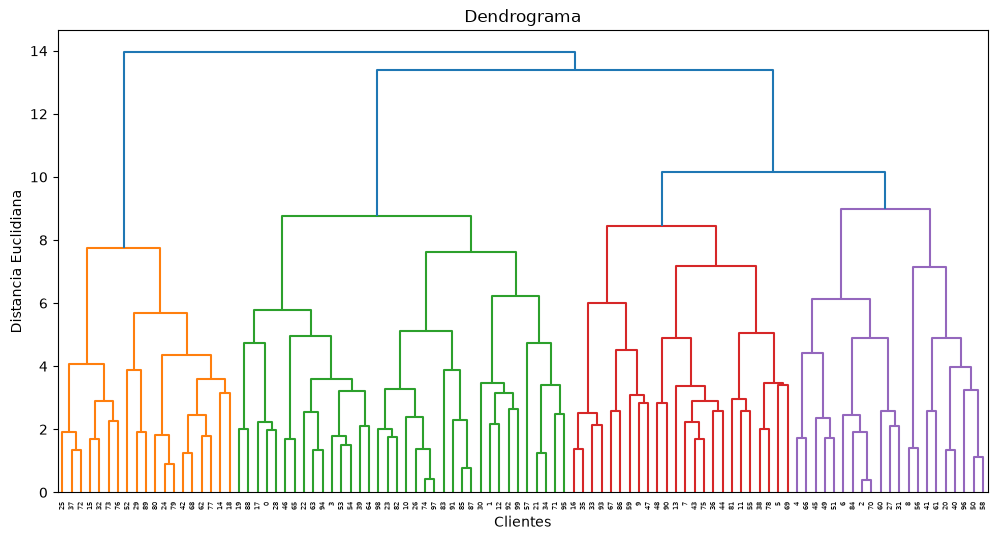

In [20]:
#Creamos el dendograma para poder decidir cuantos clusters usaremos 
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12, 6))
dendrograma = sch.dendrogram(sch.linkage(data_scale, method='ward'))
plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancia Euclidiana')
plt.show()

In [21]:
print(dendrograma['color_list'])

['C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C4', 'C0', 'C0', 'C0']


In [22]:
colores_unicos = set(dendrograma['color_list'])
colores_unicos

{'C0', 'C1', 'C2', 'C3', 'C4'}

In [23]:
num_clusters_optimo = len(colores_unicos) - 1
num_clusters_optimo

4

In [24]:
#Vamos hacer el clustering jerarquico 
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=4, linkage='ward')
grupos = cluster.fit_predict(data_scale)

In [25]:
resultado = pd.DataFrame({'Cliente': nombres, 'Cluster': grupos})
resultado.sort_values('Cluster')

,Cliente,Cluster
2,Bernard,0
4,Emilia,0
6,Philip,0
8,Xavier,0
27,Florence,0
...,...,...
72,Methodius,3
89,Stephania,3
80,Myroslava,3
68,Maura,3


In [26]:
pd.options.display.max_rows = None
resultado

,Cliente,Cluster
0,Adam,2
1,Anna,2
2,Bernard,0
3,Edward,2
4,Emilia,0
5,Fabian,1
6,Philip,0
7,Frank,1
8,Xavier,0
9,Gabriel,1


In [27]:
#Vamos a encontrar quien mas esta en el cluster 3, ya que Stephania salio en ese cluster
resultado[resultado['Cluster'] == 3]

,Cliente,Cluster
14,Isidore,3
15,Joseph,3
18,Eunice,3
24,Flavia,3
25,Flora,3
29,Helen,3
32,Lourdes,3
37,Jervis,3
42,Judith,3
52,Louise,3


In [28]:
# Ver las calificaciones de todo el clúster 3, con nombres
data_con_cluster = data.copy()
data_con_cluster['Cluster'] = grupos

cluster3 = data_con_cluster[data_con_cluster['Cluster'] == 3]
cluster3

,Cliente,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,Cluster
14,Isidore,235,65,495,335,3,26,34,295,39,3
15,Joseph,17,1,485,235,27,17,24,235,34,3
18,Eunice,265,7,485,305,33,39,34,295,39,3
24,Flavia,255,7,435,24,33,26,19,245,34,3
25,Flora,23,105,395,29,34,28,235,295,34,3
29,Helen,205,185,295,275,39,3,42,255,31,3
32,Lourdes,26,1,465,295,37,24,23,305,45,3
37,Jervis,2,45,455,27,24,26,365,255,31,3
42,Judith,245,115,465,225,36,13,31,295,38,3
52,Louise,225,205,315,295,43,34,44,275,35,3


In [29]:
#Vamos a encontrar el cliente que sea similiar a Stephania dentro del cluster 3
from scipy.spatial.distance import euclidean

# Filtra solo el clúster de Stephanía (ajusta el número si es necesario)
cluster_stephania = data_con_cluster[data_con_cluster['Cluster'] == 3].copy()

# Guarda los datos numéricos de Stephanía (sin nombre ni columna Cluster)
fila_stephania = cluster_stephania[cluster_stephania['Cliente'] == 'Stephania'].drop(columns=['Cliente', 'Cluster']).values[0]

# Calcula la distancia de Stephanía contra cada persona de su clúster
distancias = {}
for i, row in cluster_stephania.iterrows():
    nombre = row['Cliente']
    if nombre != 'Stephania':
        valores = row.drop(labels=['Cliente', 'Cluster']).values
        distancias[nombre] = euclidean(fila_stephania, valores)

# Ordena de menor a mayor distancia (el más parecido primero)
distancias_ordenadas = sorted(distancias.items(), key=lambda x: x[1])
distancias_ordenadas

[('Isidore', np.float64(83.00602387778854)),
 ('Markian', np.float64(94.75758544834287)),
 ('Judith', np.float64(96.79876032264049)),
 ('Eunice', np.float64(135.2590107904091)),
 ('Maura', np.float64(176.34908562280668)),
 ('Louise', np.float64(177.28508115461943)),
 ('Helen', np.float64(192.21602430598756)),
 ('Mykyta', np.float64(202.18803129760178)),
 ('Lourdes', np.float64(228.25862524776582)),
 ('Joseph', np.float64(258.4337439267558)),
 ('Myroslav', np.float64(320.5869616812262)),
 ('Flavia', np.float64(325.0153842512689)),
 ('Monica', np.float64(333.30616555953475)),
 ('Myroslava', np.float64(394.37291996281897)),
 ('Michael', np.float64(397.66191670815044)),
 ('Flora', np.float64(404.9209799454703)),
 ('Methodius', np.float64(429.62890964179775)),
 ('Jervis', np.float64(495.65814832402384))]

In [30]:
#Vamos a encontrar a Lydia, su cluster y cual es el cliente que es mas similiar a ella 
from scipy.spatial.distance import euclidean

def cliente_mas_similar(nombre_cliente, data_con_cluster):
    # Encuentra el clúster del cliente
    cluster_num = data_con_cluster[data_con_cluster['Cliente'] == nombre_cliente]['Cluster'].values[0]
    
    # Filtra a todos los del mismo clúster
    mismo_cluster = data_con_cluster[data_con_cluster['Cluster'] == cluster_num].copy()
    
    # Datos numéricos del cliente en cuestión
    fila_cliente = mismo_cluster[mismo_cluster['Cliente'] == nombre_cliente].drop(columns=['Cliente', 'Cluster']).values[0]
    
    # Calcula distancias contra el resto del clúster
    distancias = {}
    for i, row in mismo_cluster.iterrows():
        nombre = row['Cliente']
        if nombre != nombre_cliente:
            valores = row.drop(labels=['Cliente', 'Cluster']).values
            distancias[nombre] = euclidean(fila_cliente, valores)
    
    distancias_ordenadas = sorted(distancias.items(), key=lambda x: x[1])
    
    print(f"{nombre_cliente} pertenece al clúster {cluster_num}")
    return distancias_ordenadas

In [31]:
cliente_mas_similar('Lydia', data_con_cluster)

Lydia pertenece al clúster 2


[('Fedir', np.float64(41.569219381653056)),
 ('Ivan', np.float64(141.16656828017037)),
 ('Lubomyr', np.float64(143.41548033598048)),
 ('Anna', np.float64(169.25424662323837)),
 ('Fialka', np.float64(172.71074083565273)),
 ('Samuel', np.float64(175.50213673912918)),
 ('Teon', np.float64(205.2681173489931)),
 ('Edward', np.float64(206.48244477436816)),
 ('Irene', np.float64(208.51378851289428)),
 ('Theodore', np.float64(225.22877258467668)),
 ('Hannah', np.float64(232.89911979223967)),
 ('Marko', np.float64(252.42820761555154)),
 ('Felix', np.float64(266.32123460212483)),
 ('Adam', np.float64(278.95160870659987)),
 ('Stephan', np.float64(284.04577095954096)),
 ('Eva', np.float64(351.8962915405617)),
 ('Eugenia', np.float64(393.44631145812)),
 ('Sylvester', np.float64(399.6198193283211)),
 ('Marisol', np.float64(410.8308654422158)),
 ('John', np.float64(411.9101843848972)),
 ('Michaelina', np.float64(418.1459075490277)),
 ('Florent', np.float64(425.949527526443)),
 ('Teofila', np.float64(

In [32]:
cliente_mas_similar('Salome', data_con_cluster)

Salome pertenece al clúster 1


[('Magdalyna', np.float64(184.95675170158023)),
 ('Kalyna', np.float64(192.47337478207214)),
 ('Gabriel', np.float64(207.25829295832773)),
 ('Joachim', np.float64(239.98958310726738)),
 ('Fabian', np.float64(267.99813432186426)),
 ('Henry', np.float64(273.7206605282108)),
 ('Maya', np.float64(275.1999273255718)),
 ('Jeremiah', np.float64(291.6796187600361)),
 ('Myron', np.float64(311.61996084975044)),
 ('Mina', np.float64(326.98317999554655)),
 ('Justin', np.float64(333.6090526349667)),
 ('Leonard', np.float64(368.55800086282215)),
 ('Jacob', np.float64(376.58730727415656)),
 ('Frank', np.float64(380.2341383937008)),
 ('Isabelle', np.float64(381.255819627714)),
 ('Leon', np.float64(393.3090387977373)),
 ('Susanna', np.float64(401.0660793435416)),
 ('Eugene', np.float64(401.3016321920458)),
 ('Maria', np.float64(420.984560286954)),
 ('Matthew', np.float64(436.9004463261625)),
 ('Sebastian', np.float64(442.6703062099377)),
 ('Tamara', np.float64(445.7869446271391)),
 ('Isadore', np.float